# Oversampling Data Ecoil

# Data Ditarik Ke Dalam MySQL

![ecoil database](../image/ecoil_mysql.jpg)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import Counter
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE

In [2]:
engine = create_engine("mysql+pymysql://root:@localhost/psd")
query = "SELECT mcg, gvh, lip, chg, aac, alm1, alm2, localization_class FROM ecoli"
df = pd.read_sql(query, engine)

# INFORMASI DATASET

In [3]:
print("\nInfo Dataset:")
df


Info Dataset:


,mcg,gvh,lip,chg,aac,alm1,alm2,localization_class
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
...,...,...,...,...,...,...,...,...
331,0.74,0.56,0.48,0.5,0.47,0.68,0.30,pp
332,0.71,0.57,0.48,0.5,0.48,0.35,0.32,pp
333,0.61,0.60,0.48,0.5,0.44,0.39,0.38,pp
334,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp


# ANALISIS DISTRIBUSI KELAS

In [4]:
class_counts = df['localization_class'].value_counts().sort_index()
print("Distribusi kelas:")
print(class_counts)

class_percentages = df['localization_class'].value_counts(normalize=True).sort_index() * 100
print(f"\nPersentase distribusi kelas:")
for cls, count, pct in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f"{cls}: {count} samples ({pct:.1f}%)")

max_class_pct = class_percentages.max()
min_class_pct = class_percentages.min()
imbalance_ratio = max_class_pct / min_class_pct

print(f"\nANALISIS KESEIMBANGAN KELAS")
print(f"Kelas terbanyak: {class_percentages.idxmax()} ({max_class_pct:.1f}%)")
print(f"Kelas tersedikit: {class_percentages.idxmin()} ({min_class_pct:.1f}%)")
print(f"Rasio ketidakseimbangan: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 3:
    balance_status = "TIDAK SEIMBANG (Imbalanced)"
elif imbalance_ratio > 1.5:
    balance_status = "SEDIKIT TIDAK SEIMBANG"
else:
    balance_status = "SEIMBANG (Balanced)"

print(f"Status: {balance_status}")

Distribusi kelas:
localization_class
cp     143
im      77
imL      2
imS      2
imU     35
om      20
omL      5
pp      52
Name: count, dtype: int64

Persentase distribusi kelas:
cp: 143 samples (42.6%)
im: 77 samples (22.9%)
imL: 2 samples (0.6%)
imS: 2 samples (0.6%)
imU: 35 samples (10.4%)
om: 20 samples (6.0%)
omL: 5 samples (1.5%)
pp: 52 samples (15.5%)

ANALISIS KESEIMBANGAN KELAS
Kelas terbanyak: cp (42.6%)
Kelas tersedikit: imL (0.6%)
Rasio ketidakseimbangan: 71.5:1
Status: TIDAK SEIMBANG (Imbalanced)


# VISUALISASI DISTRIBUSI KELAS

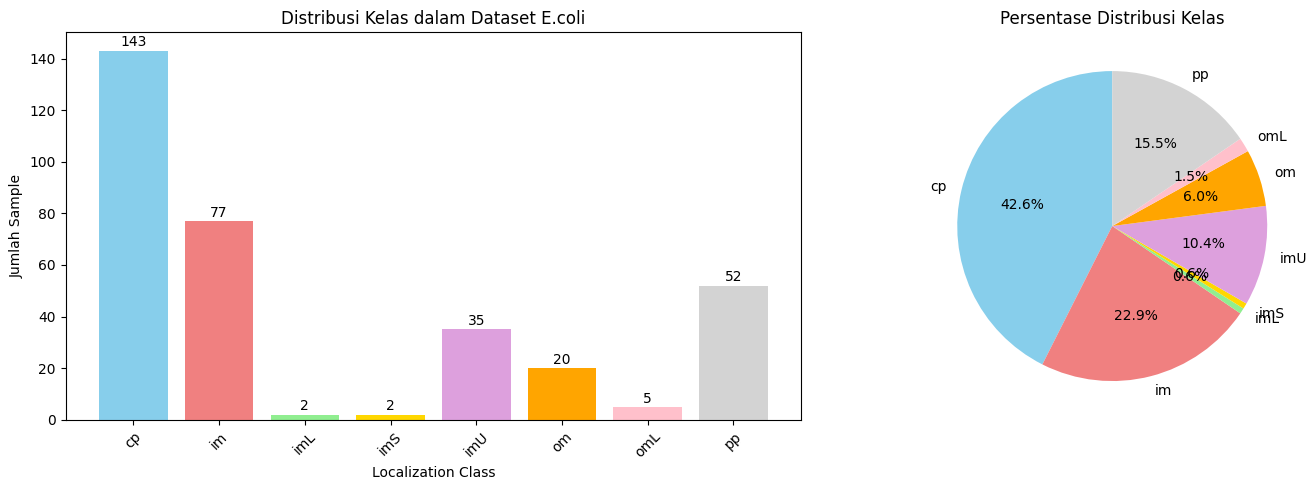

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(class_counts.index, class_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'lightgray'])

plt.xlabel('Localization Class')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas dalam Dataset E.coli')
plt.xticks(rotation=45)

for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom')

# Pie chart
plt.subplot(1, 2, 2)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'lightgray']
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
        colors=colors[:len(class_counts)], startangle=90)
plt.title('Persentase Distribusi Kelas')

plt.tight_layout()
plt.show()


# Data dalam Scatter Plot Menggunakan PCA

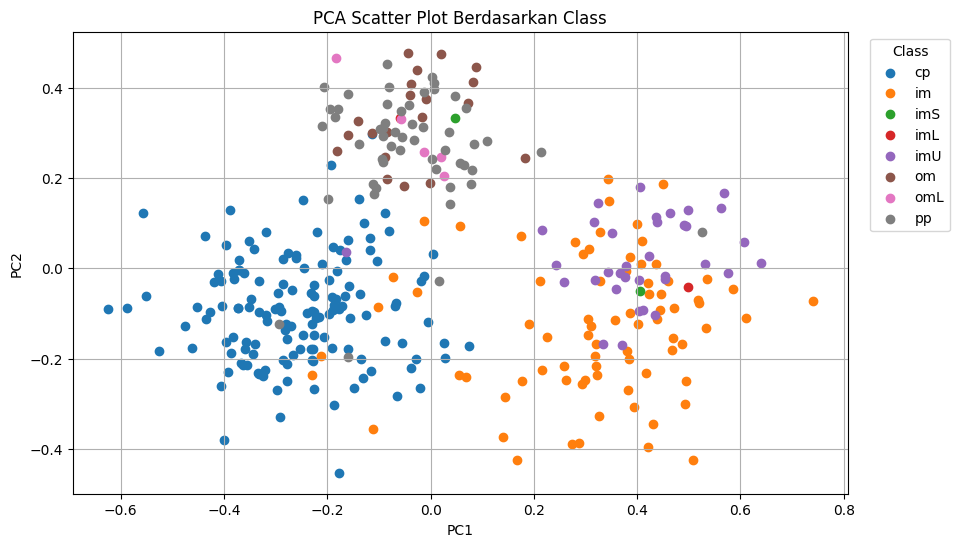

Data setelah di transformasi PCA : 


,PC1,PC2,localization_class
0,-0.285601,-0.035274,cp
1,-0.290838,-0.330159,cp
2,-0.104676,0.015248,cp
3,-0.087943,0.122218,cp
4,-0.366268,-0.210366,cp
...,...,...,...
331,0.084233,0.274803,pp
332,-0.139026,0.274116,pp
333,-0.111904,0.187103,pp
334,-0.106204,0.178851,pp


In [6]:
X = df.drop(columns=["localization_class"])
y = df["localization_class"]

# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

data_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

data_pca['localization_class'] = y
data_pca.to_csv('pca_ecoli.csv', index=False)


plt.figure(figsize=(10,6))
for label in data_pca['localization_class'].unique():
    subset = data_pca[data_pca['localization_class'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Scatter Plot Berdasarkan Class")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid()

plt.show()

print("Data setelah di transformasi PCA : ")
data_pca


# Lakukan penyeimbangan data menggunakan ADASYN dan SMOTE

## Preprocessing Penyeimbangan Data Menggunakan ADASYN

In [7]:
nt = X
ns = y

temp = sorted(class_counts)

for i in range(0, 7):
    n = temp[i] - 1
    nt, ns = ADASYN(n_neighbors=n, sampling_strategy='minority').fit_resample(nt, ns)

print(f"{sorted(Counter(ns).items())}")

[('cp', 143), ('im', 154), ('imL', 142), ('imS', 142), ('imU', 145), ('om', 143), ('omL', 143), ('pp', 144)]


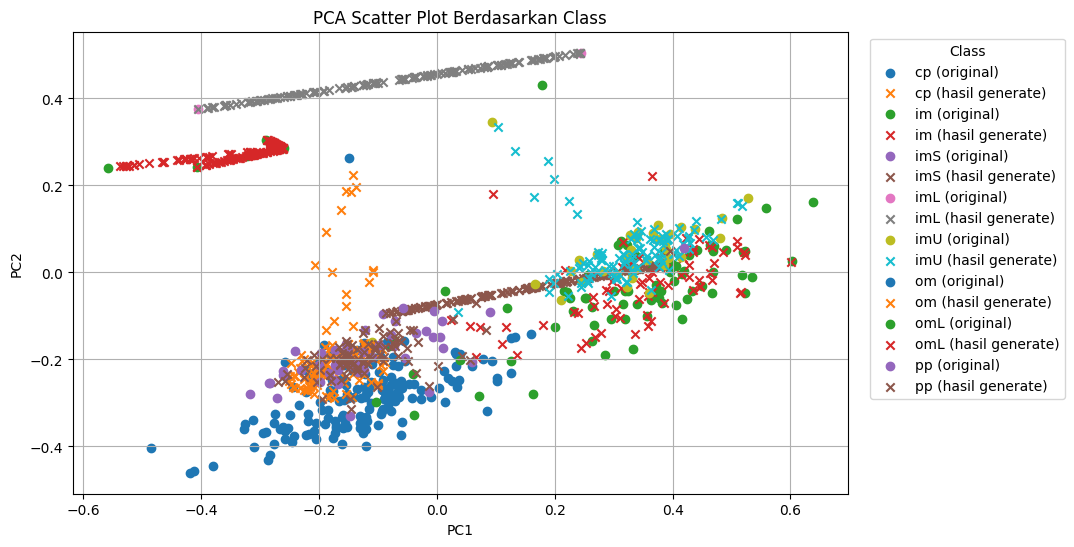

In [8]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(nt)

data_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
data_pca['localization_class'] = ns

data_pca['is_generated'] = ['original'] * len(X) + ['synthetic'] * (len(nt) - len(X))

plt.figure(figsize=(10,6))

for label in data_pca['localization_class'].unique():
    subset_original = data_pca[(data_pca['localization_class'] == label) & (data_pca['is_generated'] == 'original')]
    subset_synthetic = data_pca[(data_pca['localization_class'] == label) & (data_pca['is_generated'] == 'synthetic')]
    
    plt.scatter(subset_original['PC1'], subset_original['PC2'], label=f"{label} (original)", marker='o')
    plt.scatter(subset_synthetic['PC1'], subset_synthetic['PC2'], label=f"{label} (hasil generate)", marker='x')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot Berdasarkan Class")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid()
plt.show()

## Preprocessing Penyeimbangan Data Menggunakan SMOTE

In [9]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = smote.fit_resample(X, y)
print(f"{sorted(Counter(y_res).items())}")

[('cp', 143), ('im', 143), ('imL', 143), ('imS', 143), ('imU', 143), ('om', 143), ('omL', 143), ('pp', 143)]


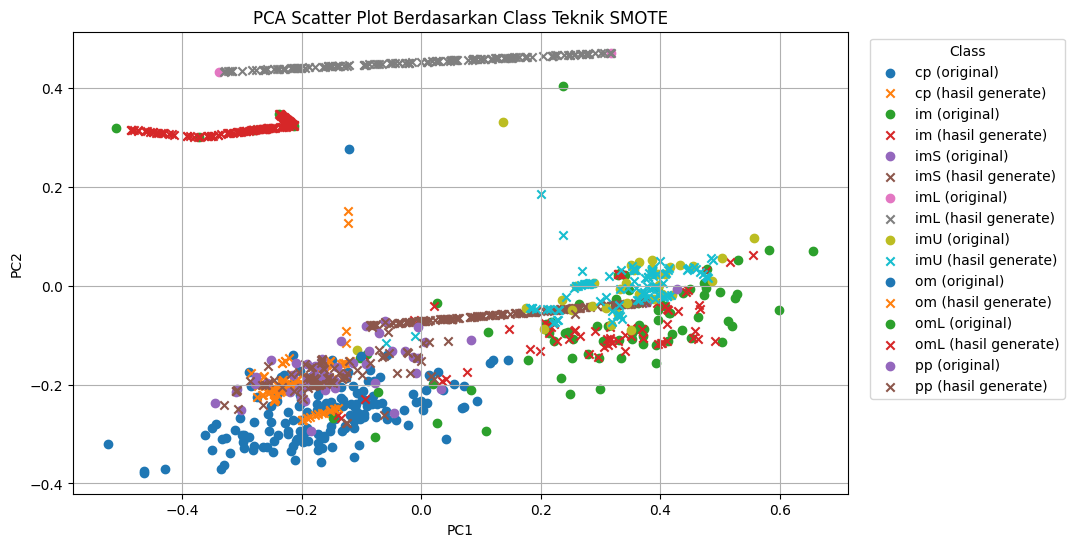

In [10]:

pcba = PCA(n_components=2)
pca_result = pcba.fit_transform(X_res)

data_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
data_pca['localization_class'] = y_res

data_pca['is_generated'] = ['original'] * len(X) + ['synthetic'] * (len(X_res) - len(X))

plt.figure(figsize=(10,6))

for label in data_pca['localization_class'].unique():
    subset_original = data_pca[(data_pca['localization_class'] == label) & (data_pca['is_generated'] == 'original')]
    subset_synthetic = data_pca[(data_pca['localization_class'] == label) & (data_pca['is_generated'] == 'synthetic')]
    
    plt.scatter(subset_original['PC1'], subset_original['PC2'], label=f"{label} (original)", marker='o')
    plt.scatter(subset_synthetic['PC1'], subset_synthetic['PC2'], label=f"{label} (hasil generate)", marker='x')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot Berdasarkan Class Teknik SMOTE")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid()
plt.show()

# Perbandingan penyeimbangan data menggunakan SMOTE dan ADASYN

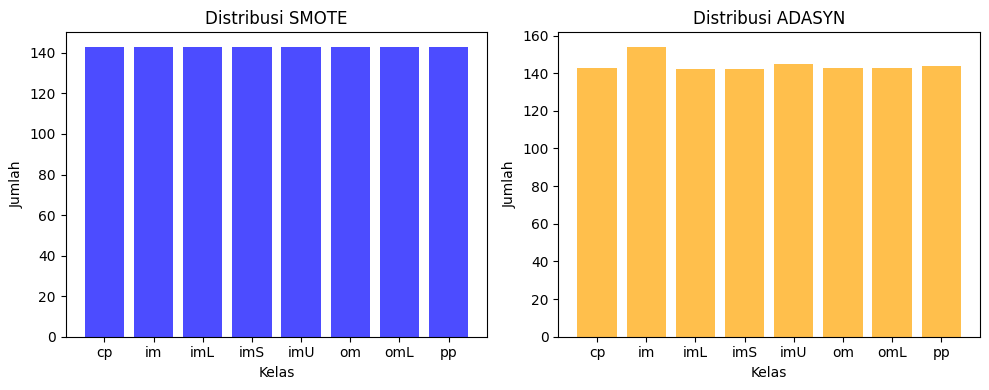

In [11]:

data = np.array(sorted(Counter(y_res).items()))
kelas, dist = np.hsplit(data, 2)
kelas = kelas.ravel().tolist()
dist = dist.astype(int).ravel().tolist()

data2 = np.array(sorted(Counter(ns).items()))
kelas2, dist2 = np.hsplit(data2, 2)
kelas2 = kelas2.ravel().tolist()
dist2 = dist2.astype(int).ravel().tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(kelas, dist, color="blue", alpha=0.7)
ax1.set_title("Distribusi SMOTE")
ax1.set_xlabel("Kelas")
ax1.set_ylabel("Jumlah")

ax2.bar(kelas2, dist2, color="orange", alpha=0.7)
ax2.set_title("Distribusi ADASYN")
ax2.set_xlabel("Kelas")
ax2.set_ylabel("Jumlah")

plt.tight_layout()
plt.show()